# Pokedex Project: 
---

### Opening Question
**What distinguishes legendary Pokemon from non‑legendary ones? Is it just higher stats, or do certain types and physical traits also play a role?**

### Objective
To explore the Pokemon dataset and identify the key characteristics that separate legendary from non‑legendary species. I'll be examining type distributions, stat differences, generational trends, and type combinations. Then, build a logistic regression model to predict legendary status and interpret which features are most influential.

### Dataset Overview
- **Sample Size**: 800+ Pokemon from multiple generations
- **Variables**: name, type1, type2, hp, attack, defence, sp_attack, sp_defence, speed, base_total, capture_rate, base_happiness, weight_kg, height_m, generation, is_legendary, and more
- **Analysis Approach**: Exploratory Data Analysis [EDA] followed by logistic regression modelling.

In [69]:
# import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# visualisation style
sns.set_style("whitegrid")

# colour scheme for consistency
primary = "#d59de3"
secondary = "#345882"
success = "#2ca02c"
danger = "#d62728"
gradient = ["#d59de3", "#b291d6", "#8c84c7", "#6477b6", "#48689d", "#345882"]

In [70]:
# colour mapping
typecolours = {
    "normal": "#c4c4b8",
    "fire": "#ffa06a",
    "water": "#7bafff",
    "grass": "#8ed66f",
    "electric": "#ffe26b",
    "ice": "#b5eae7",
    "fighting": "#dc6b66",
    "poison": "#be73bc",
    "ground": "#e8d08d",
    "flying": "#c1b3f9",
    "psychic": "#fa82a7",
    "bug": "#c2d16c",
    "rock": "#d1c37b",
    "ghost": "#9d8bb9",
    "dragon": "#9973ff",
    "dark": "#8e7d73",
    "steel": "#cacad8",
    "fairy": "#f5aedb",
    "none": "#ba9ce258"
}

### 1. Data Loading and Viewing
Before beginning the EDA, I need the dataset to be present first, of course. Here's a brief look into what to expect from the data.

In [71]:
# load dataset
path = "pokemon.csv"
df = pd.read_csv(path)

# shape and types
print(f"Shape of the dataset: {df.shape}")
print(f"\nData types:\n{df.dtypes}")

Shape of the dataset: (801, 41)

Data types:
abilities                str
against_bug          float64
against_dark         float64
against_dragon       float64
against_electric     float64
against_fairy        float64
against_fight        float64
against_fire         float64
against_flying       float64
against_ghost        float64
against_grass        float64
against_ground       float64
against_ice          float64
against_normal       float64
against_poison       float64
against_psychic      float64
against_rock         float64
against_steel        float64
against_water        float64
attack                 int64
base_egg_steps         int64
base_happiness         int64
base_total             int64
capture_rate             str
classfication            str
defense                int64
experience_growth      int64
height_m             float64
hp                     int64
japanese_name            str
name                     str
percentage_male      float64
pokedex_number         int6

In [72]:
print("First 5 records:")
df.head()

First 5 records:


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [73]:
print("Last 5 records:")
df.tail()

Last 5 records:


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
796,['Beast Boost'],0.25,1.0,0.5,2.0,0.5,1.0,2.0,0.5,1.0,...,NaN,797,107,101,61,steel,flying,999.9,7,1
797,['Beast Boost'],1.00,1.0,0.5,0.5,0.5,2.0,4.0,1.0,1.0,...,NaN,798,59,31,109,grass,steel,0.1,7,1
798,['Beast Boost'],2.00,0.5,2.0,0.5,4.0,2.0,0.5,1.0,0.5,...,NaN,799,97,53,43,dark,dragon,888.0,7,1
799,['Prism Armor'],2.00,2.0,1.0,1.0,1.0,0.5,1.0,1.0,2.0,...,NaN,800,127,89,79,psychic,NaN,230.0,7,1
800,['Soul-Heart'],0.25,0.5,0.0,1.0,0.5,1.0,2.0,0.5,1.0,...,NaN,801,130,115,65,steel,fairy,80.5,7,1


In [74]:
print("Descriptive statistics:")
df.describe(include="all")

Descriptive statistics:


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
count,801,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,...,703.000000,801.000000,801.000000,801.000000,801.000000,801,417,781.000000,801.000000,801.000000
unique,482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,18,18,NaN,NaN,NaN
top,['Levitate'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,water,flying,NaN,NaN,NaN
freq,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,114,95,NaN,NaN,NaN
mean,NaN,0.996255,1.057116,0.968789,1.073970,1.068976,1.065543,1.135456,1.192884,0.985019,...,55.155761,401.000000,71.305868,70.911361,66.334582,NaN,NaN,61.378105,3.690387,0.087391
std,NaN,0.597248,0.438142,0.353058,0.654962,0.522167,0.717251,0.691853,0.604488,0.558256,...,20.261623,231.373075,32.353826,27.942501,28.907662,NaN,NaN,109.354766,1.930420,0.282583
min,NaN,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,...,0.000000,1.000000,10.000000,20.000000,5.000000,NaN,NaN,0.100000,1.000000,0.000000
25%,NaN,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,0.500000,1.000000,1.000000,...,50.000000,201.000000,45.000000,50.000000,45.000000,NaN,NaN,9.000000,2.000000,0.000000
50%,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,50.000000,401.000000,65.000000,66.000000,65.000000,NaN,NaN,27.300000,4.000000,0.000000
75%,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,50.000000,601.000000,91.000000,90.000000,85.000000,NaN,NaN,64.800000,5.000000,0.000000


In [75]:
# data quality check
print("Missing values:")
missingdata = df.isnull().sum()
missingpct = (missingdata / len(df) * 100).round(2)
print(pd.DataFrame({"Missing Values": missingdata, "Percentage": missingpct}))
print("Duplicate values: ",df.duplicated().sum())

Missing values:
                   Missing Values  Percentage
abilities                       0        0.00
against_bug                     0        0.00
against_dark                    0        0.00
against_dragon                  0        0.00
against_electric                0        0.00
against_fairy                   0        0.00
against_fight                   0        0.00
against_fire                    0        0.00
against_flying                  0        0.00
against_ghost                   0        0.00
against_grass                   0        0.00
against_ground                  0        0.00
against_ice                     0        0.00
against_normal                  0        0.00
against_poison                  0        0.00
against_psychic                 0        0.00
against_rock                    0        0.00
against_steel                   0        0.00
against_water                   0        0.00
attack                          0        0.00
base_egg_steps    

### 2. Types Analysis
To start off the EDA, I'll be analysing the primary and secondary types of the Pokemon present in the dataset. Also mention how these types are proportioned, and check whether a primary type can be a secondary type.

In [76]:
# distribution of pokemon types
type1 = df["type1"].value_counts()
type1pct = (type1 / type1.sum() * 100).round(2)

print("Distribution of Pokemon by Type1:")
pd.DataFrame({"Count": type1, "Percentage": type1pct}) 

Distribution of Pokemon by Type1:


,Count,Percentage
type1,,
water,114,14.23
normal,105,13.11
grass,78,9.74
bug,72,8.99
psychic,53,6.62
fire,52,6.49
rock,45,5.62
electric,39,4.87
poison,32,4.00


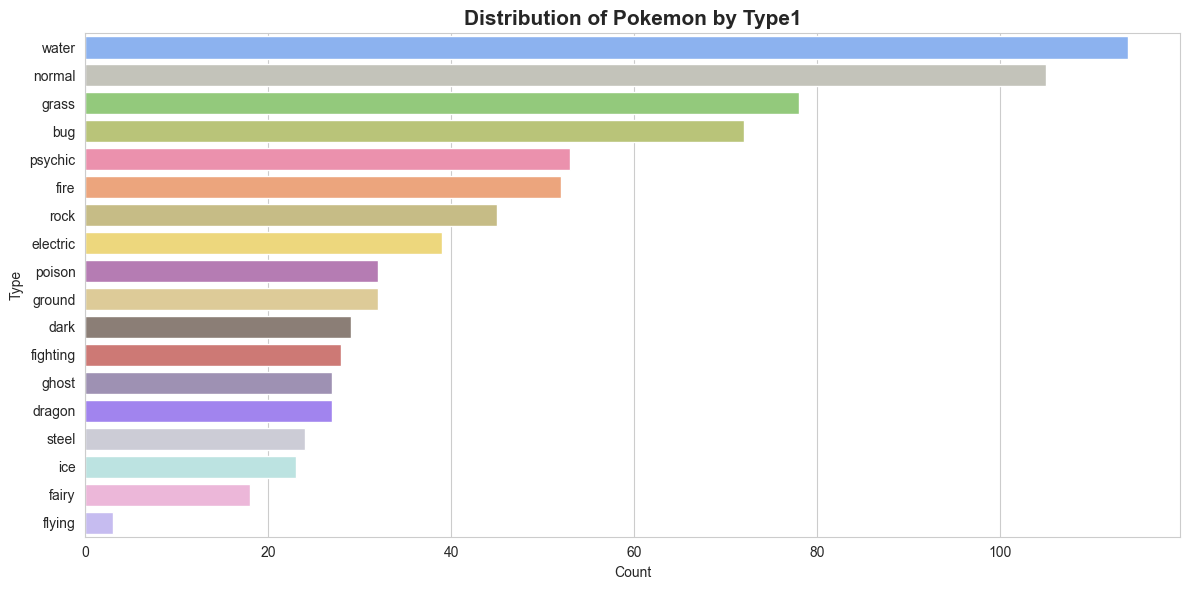

In [77]:
# visualisation for type1
colours1 = [typecolours[t] for t in type1pct.index]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=type1.values, y=type1.index, palette=colours1, ax=ax)
ax.set_title("Distribution of Pokemon by Type1", fontsize=15, fontweight="bold")
ax.set_xlabel("Count")
ax.set_ylabel("Type")
plt.tight_layout()
plt.show()

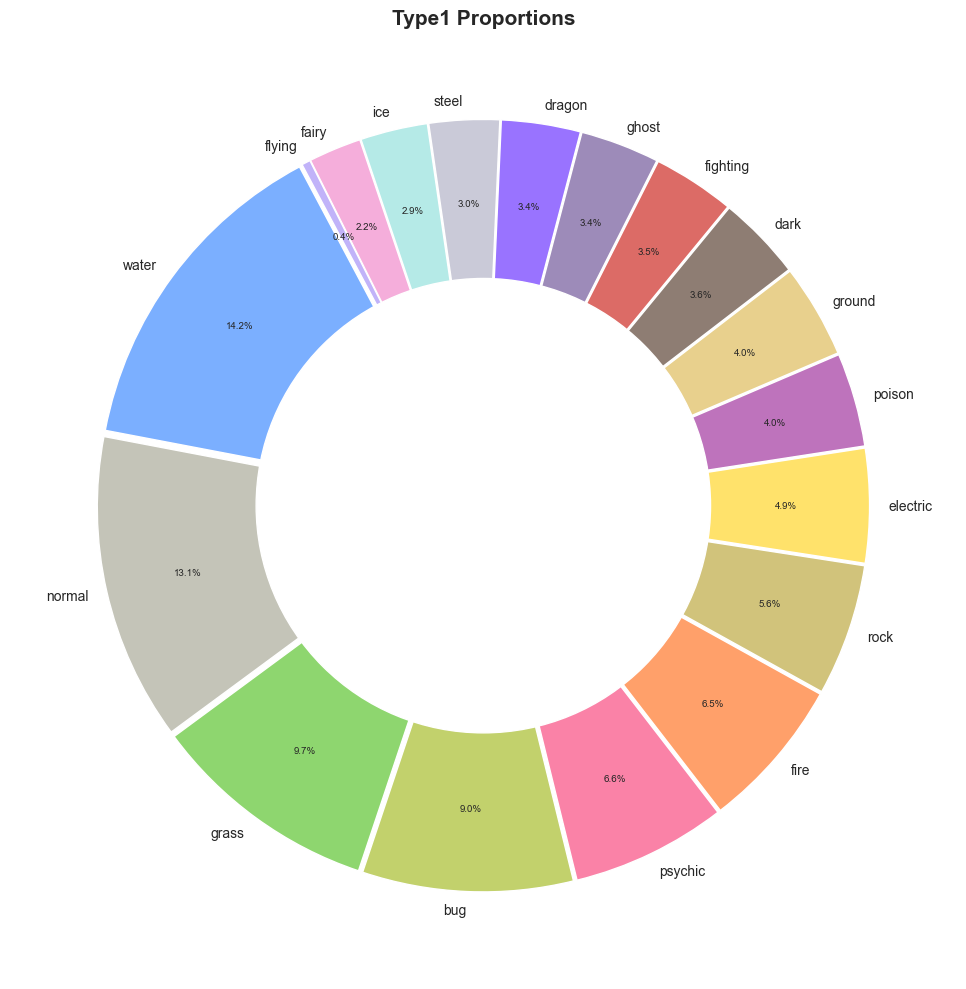

In [78]:
fig, ax = plt.subplots(figsize=(12, 10))
_, txtlabels, autotxt = plt.pie(type1pct, labels=type1pct.index, labeldistance = 1.05, autopct='%1.1f%%', startangle=478, pctdistance=0.78, colors=colours1, explode = [0.02] * len(type1pct), wedgeprops={"edgecolor": "white", "linewidth": 1})
centre = plt.Circle((0, 0), 0.6, fc="white")
ax.add_artist(centre)
for txt1 in txtlabels:
    txt1.set_fontsize(10)
for txt2 in autotxt:
    txt2.set_fontsize(7)
ax.set_title("Type1 Proportions", fontsize=15, fontweight="bold", ha="center")
plt.tight_layout()
plt.show()

In [79]:
type2 = df["type2"].fillna("none").value_counts() # to properly show the null values present
type2pct = (type2 / type2.sum() * 100).round(2)

print("Distribution of Pokemon by Type2:")
pd.DataFrame({"Count": type2, "Percentage": type2pct})

Distribution of Pokemon by Type2:


,Count,Percentage
type2,,
none,384,47.94
flying,95,11.86
poison,34,4.24
ground,34,4.24
fairy,29,3.62
psychic,29,3.62
fighting,25,3.12
steel,22,2.75
dark,21,2.62


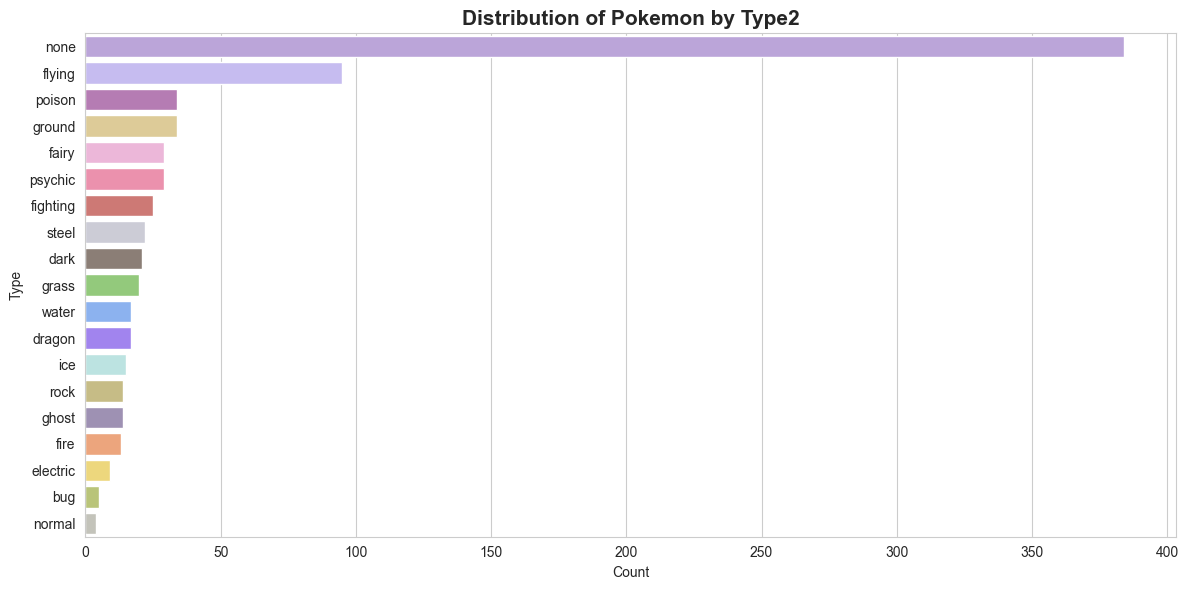

In [80]:
# visualisation for type2
colours2 = [typecolours[t] for t in type2pct.index]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=type2.values, y=type2.index, palette=colours2, ax=ax)
ax.set_title("Distribution of Pokemon by Type2", fontsize=15, fontweight="bold")
ax.set_xlabel("Count")
ax.set_ylabel("Type")
plt.tight_layout()
plt.show()

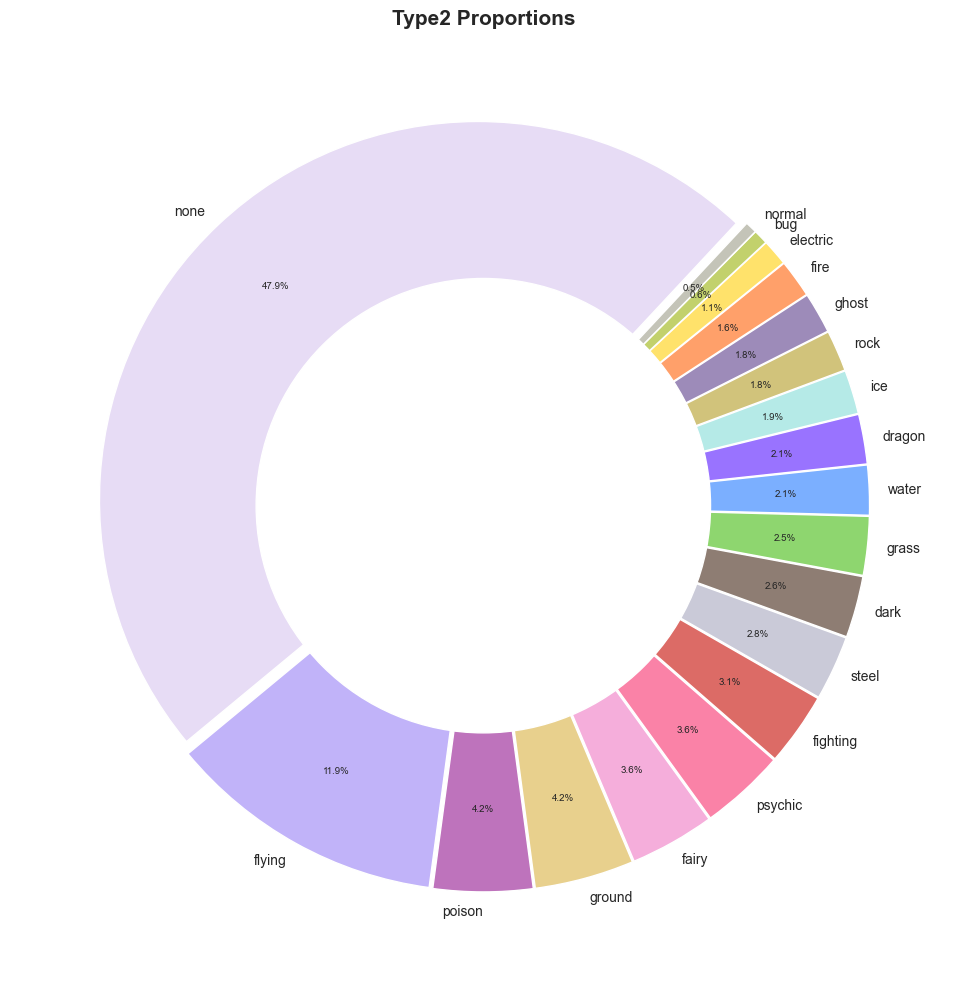

In [81]:
fig, ax = plt.subplots(figsize=(12, 10))
_, txtlabels, autotxt = plt.pie(type2pct, labels=type2pct.index, labeldistance = 1.05, autopct='%1.1f%%', pctdistance=0.78, startangle=47, colors=colours2, explode = [0.02] * len(type2pct), wedgeprops={"edgecolor": "white", "linewidth": 1})
centre = plt.Circle((0, 0), 0.6, fc="white")
ax.add_artist(centre)
for txt1 in txtlabels:
    txt1.set_fontsize(10)
for txt2 in autotxt:
    txt2.set_fontsize(7)
ax.set_title("Type2 Proportions", fontsize=15, fontweight="bold", ha="center")
plt.tight_layout()
plt.show()

In [82]:
# overlapping types
overlap = pd.DataFrame({"Type1": type1, "Type2": type2}).dropna()
overlap["Total"] = overlap["Type1"] + overlap["Type2"]
overlap["% of Overlap"] = ((overlap["Total"] / overlap["Total"].sum()) * 100).round(2)
overlap

,Type1,Type2,Total,% of Overlap
bug,72.0,5,77.0,6.32
dark,29.0,21,50.0,4.11
dragon,27.0,17,44.0,3.61
electric,39.0,9,48.0,3.94
fairy,18.0,29,47.0,3.86
fighting,28.0,25,53.0,4.35
fire,52.0,13,65.0,5.34
flying,3.0,95,98.0,8.05
ghost,27.0,14,41.0,3.37
grass,78.0,20,98.0,8.05


### 3. Pokemon Classification: Single vs Dual Type

Here I check if a Pokemon has a secondary type. The majority are dual‑type, and I also examine how base total compares between the two classes.

Pokemon class distribution:
pokemon_class
Dual      417
Single    384
Name: count, dtype: int64

Percentages:
pokemon_class
Dual      52.06
Single    47.94
Name: count, dtype: float64


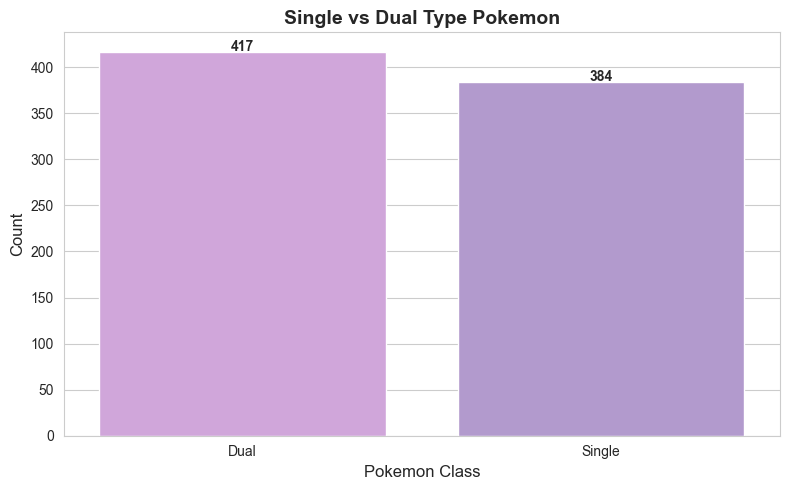


Average base total by class:
                 mean  median
pokemon_class                
Dual           445.89   464.0
Single         409.35   405.0


In [ ]:
# create pokemon class
df["poke_class"] = df["type2"].apply(lambda x: "Dual" if pd.notna(x) else "Single")
classct = df["poke_class"].value_counts()

print("Pokemon class distribution:")
print(classct)
print(f"\nPercentages:")
print((classct / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=classct.index, y=classct.values, palette=gradient, ax=ax)
ax.set_title("Single vs Dual Type Pokemon", fontsize=14, fontweight="bold")
ax.set_xlabel("Pokemon Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
for i, v in enumerate(classct.values):
    ax.text(i, v + 1, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nAverage base total by class:")
print(df.groupby("poke_class")["base_total"].agg(["mean", "median"]).round(2))

### 4. Generation Analysis

I look at how many Pokemon appear per generation and what proportion of them are legendary. Later generations tend to introduce more legendaries.

Generation distribution:
generation
1    151
2    100
3    135
4    107
5    156
6     72
7     80
Name: count, dtype: int64

Percentages:
generation
1    18.85
2    12.48
3    16.85
4    13.36
5    19.48
6     8.99
7     9.99
Name: count, dtype: float64


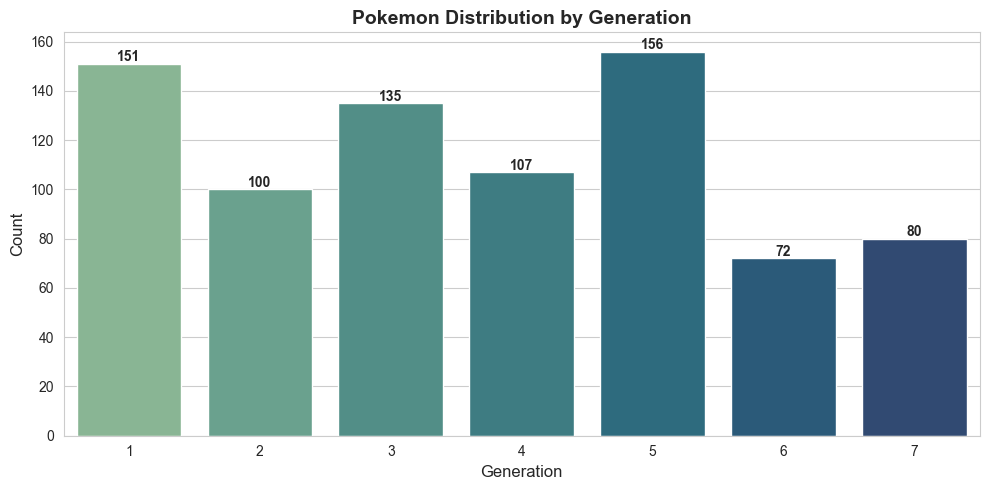

Legendary distribution by generation:
is_legendary    0   1
generation           
1             146   5
2              94   6
3             125  10
4              94  13
5             143  13
6              66   6
7              63  17

Percentage legendary by generation:
is_legendary      0      1
generation                
1             96.69   3.31
2             94.00   6.00
3             92.59   7.41
4             87.85  12.15
5             91.67   8.33
6             91.67   8.33
7             78.75  21.25


In [84]:
# generation distribution
gen_counts = df["generation"].value_counts().sort_index()
print("Generation distribution:")
print(gen_counts)
print(f"\nPercentages:")
print((gen_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=gen_counts.index, y=gen_counts.values, palette="crest", ax=ax)
ax.set_title("Pokemon Distribution by Generation", fontsize=14, fontweight="bold")
ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
for i, v in enumerate(gen_counts.values):
    ax.text(i, v + 1, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

# legendary by generation
legendary_by_gen = pd.crosstab(df["generation"], df["is_legendary"])
print("Legendary distribution by generation:")
print(legendary_by_gen)

legendary_by_gen_pct = pd.crosstab(df["generation"], df["is_legendary"], normalize="index") * 100
print("\nPercentage legendary by generation:")
print(legendary_by_gen_pct.round(2))

### 5. Stat Distribution Analysis

Legendary Pokemon have significantly higher stats across the board. The boxplots below show the clear separation between the two groups.

Average stats by legendary status:
                 hp  attack  defense  sp_attack  sp_defense  speed  \
is_legendary                                                         
0             66.42   74.84    70.48      67.24       67.95  63.55   
1             95.43  109.36    99.40     113.76      101.89  95.43   

              base_total  count  
is_legendary                     
0                 410.48    731  
1                 615.26     70  


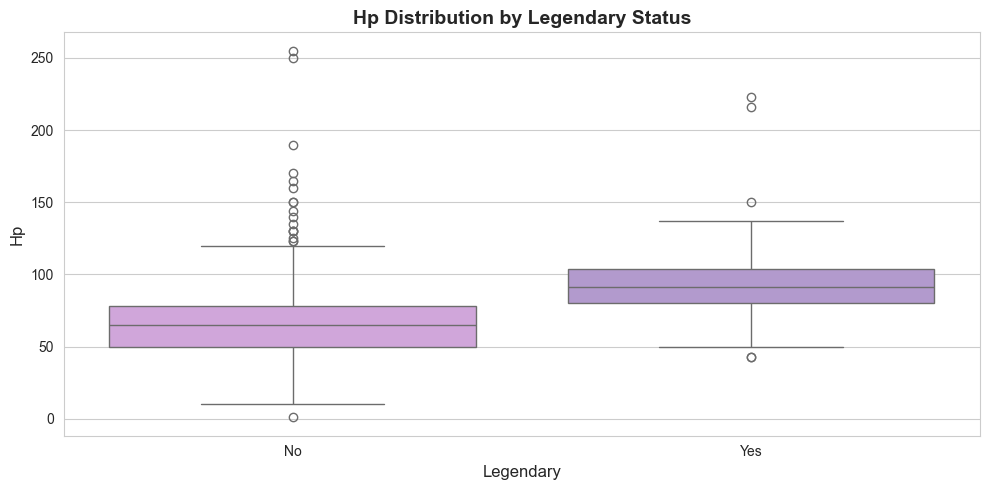

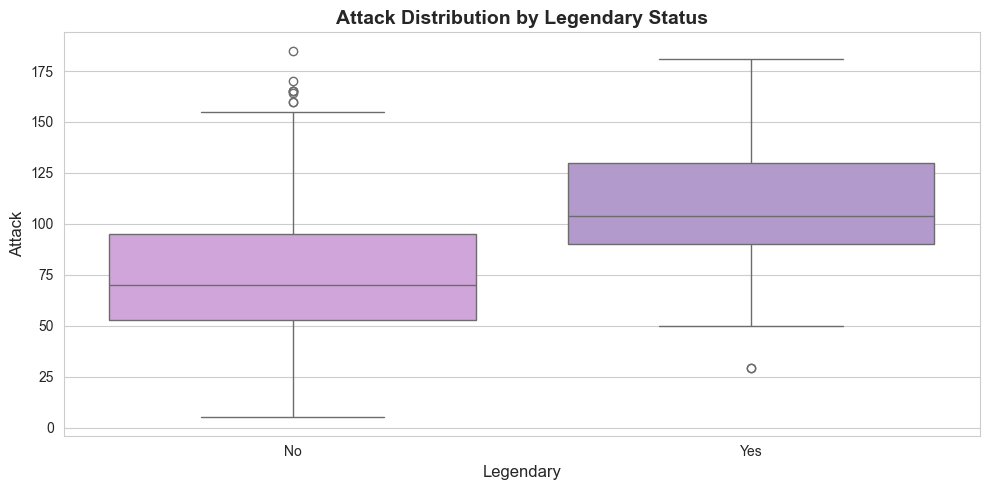

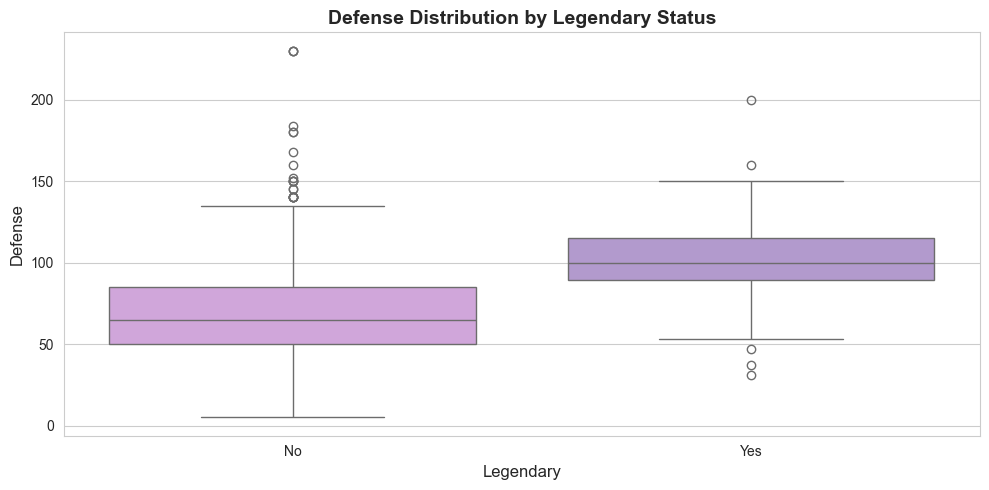

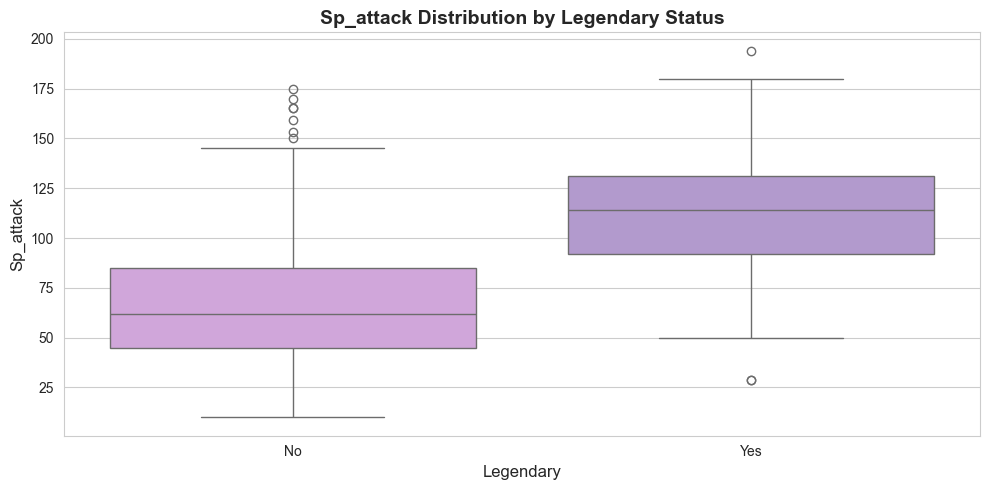

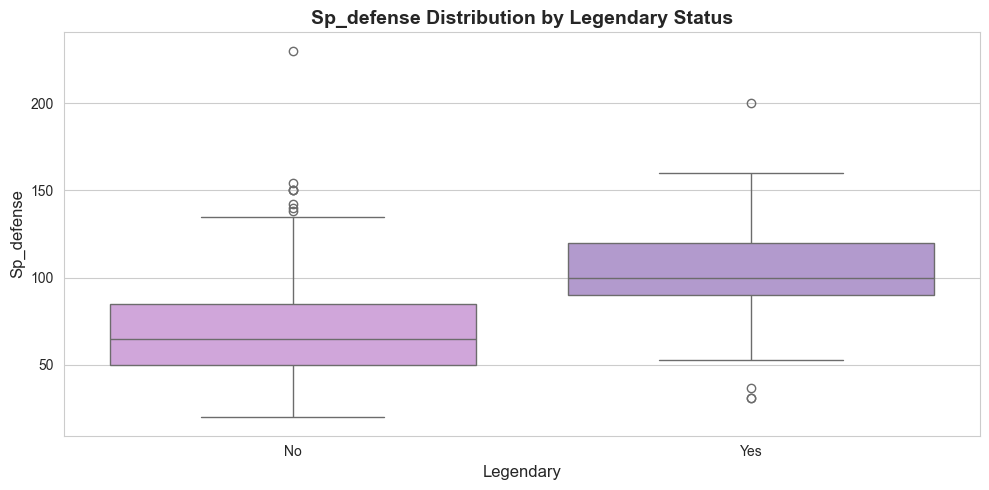

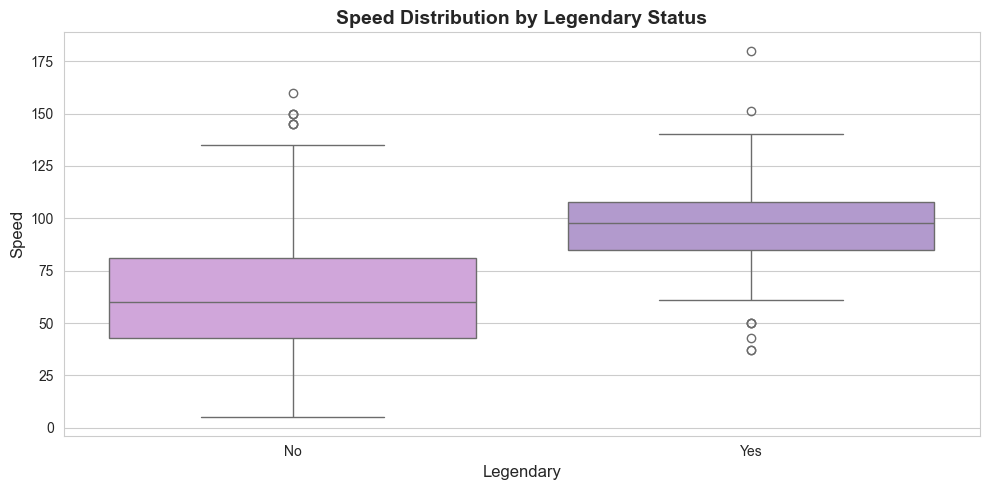

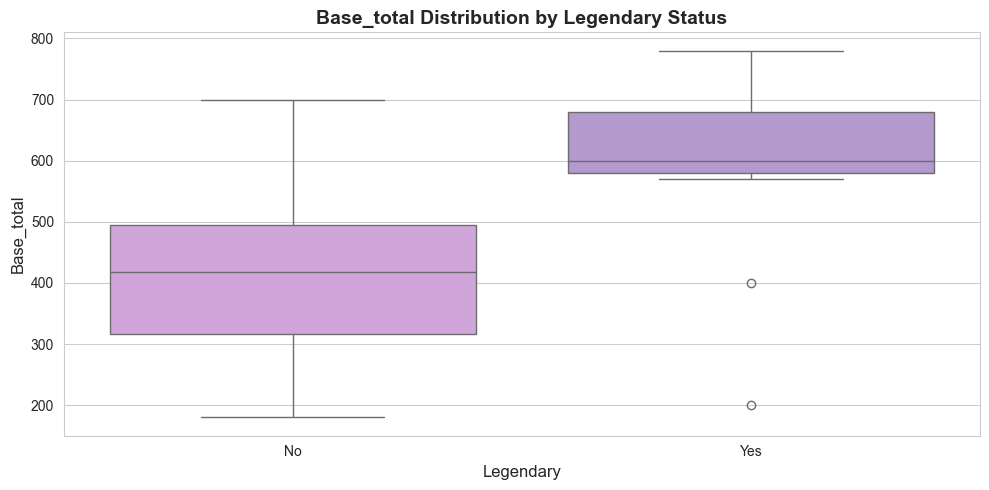

In [85]:
stat_cols = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed", "base_total"]

print("Average stats by legendary status:")
stat_comparison = df.groupby("is_legendary")[stat_cols].mean().round(2)
stat_comparison["count"] = df.groupby("is_legendary").size()
print(stat_comparison)

# boxplot for each stat
for col in stat_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="is_legendary", y=col, palette=gradient, ax=ax)
    ax.set_title(f"{col.capitalize()} Distribution by Legendary Status", fontsize=14, fontweight="bold")
    ax.set_xlabel("Legendary", fontsize=12)
    ax.set_ylabel(col.capitalize(), fontsize=12)
    ax.set_xticklabels(["No", "Yes"])
    plt.tight_layout()
    plt.show()

### 6. Correlation Analysis

The correlation matrix reveals that base total and special attack have the strongest positive correlation with legendary status, while capture rate has a strong negative correlation [legendary Pokemon are harder to catch].

In [101]:
df["capture_rate"] = pd.to_numeric(df["capture_rate"], errors="coerce")
numeric_cols = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed", "base_total", "capture_rate", "base_happiness", "weight_kg", "height_m", "generation", "is_legendary"]
correlation_matrix = df[numeric_cols].corr()
print("Correlation matrix:")
correlation_matrix.round(3)

Correlation matrix:


,hp,attack,defense,sp_attack,sp_defense,speed,base_total,capture_rate,base_happiness,weight_kg,height_m,generation,is_legendary
hp,1.000,0.411,0.242,0.366,0.367,0.161,0.621,-0.476,-0.108,0.428,0.478,0.074,0.308
attack,0.411,1.000,0.469,0.368,0.266,0.353,0.730,-0.497,-0.252,0.382,0.423,0.101,0.303
defense,0.242,0.469,1.000,0.242,0.526,0.008,0.630,-0.447,-0.192,0.424,0.362,0.058,0.266
sp_attack,0.366,0.368,0.242,1.000,0.511,0.439,0.741,-0.520,-0.229,0.245,0.353,0.070,0.406
sp_defense,0.367,0.266,0.526,0.511,1.000,0.226,0.717,-0.523,-0.150,0.307,0.328,0.049,0.343
speed,0.161,0.353,0.008,0.439,0.226,1.000,0.548,-0.384,-0.149,0.051,0.202,-0.020,0.312
base_total,0.621,0.730,0.630,0.741,0.717,0.548,1.000,-0.712,-0.275,0.458,0.535,0.084,0.485
capture_rate,-0.476,-0.497,-0.447,-0.520,-0.523,-0.384,-0.712,1.000,0.168,-0.327,-0.383,-0.053,-0.328
base_happiness,-0.108,-0.252,-0.192,-0.229,-0.150,-0.149,-0.275,0.168,1.000,-0.406,-0.343,-0.116,-0.413
weight_kg,0.428,0.382,0.424,0.245,0.307,0.051,0.458,-0.327,-0.406,1.000,0.627,0.086,0.393


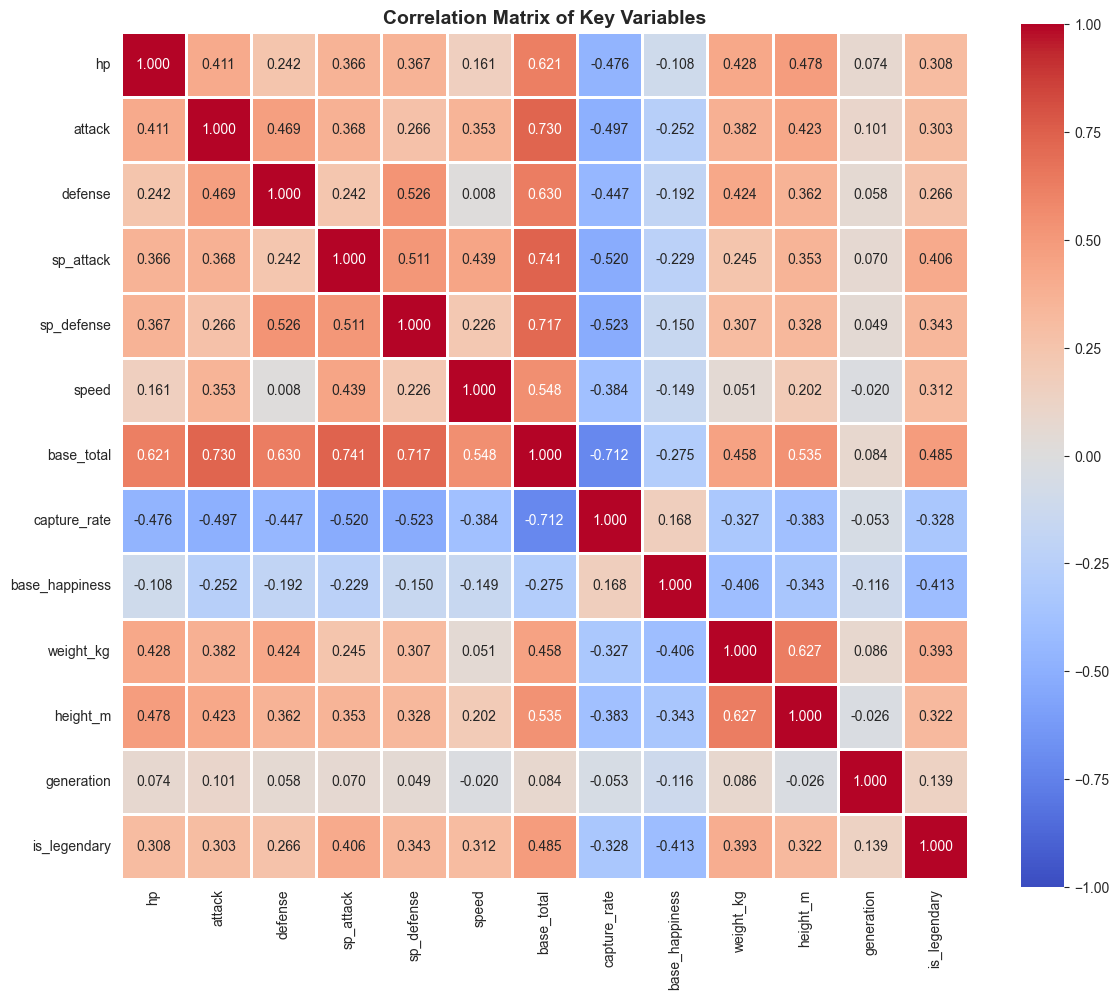

In [100]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".3f", center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix of Key Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7. Type vs Legendary Relationship

Certain types are much more likely to be legendary. The bar chart below shows the percentage of legendary Pokemon for each primary type.

Type1 vs Legendary distribution:
is_legendary    0   1  All
type1                     
bug            69   3   72
dark           26   3   29
dragon         20   7   27
electric       34   5   39
fairy          17   1   18
fighting       28   0   28
fire           47   5   52
flying          2   1    3
ghost          26   1   27
grass          74   4   78
ground         30   2   32
ice            21   2   23
normal        102   3  105
poison         32   0   32
psychic        36  17   53
rock           41   4   45
steel          18   6   24
water         108   6  114
All           731  70  801

Percentage legendary by type:
is_legendary       0      1
type1                      
bug            95.83   4.17
dark           89.66  10.34
dragon         74.07  25.93
electric       87.18  12.82
fairy          94.44   5.56
fighting      100.00   0.00
fire           90.38   9.62
flying         66.67  33.33
ghost          96.30   3.70
grass          94.87   5.13
ground         93.75   6.25
ice  

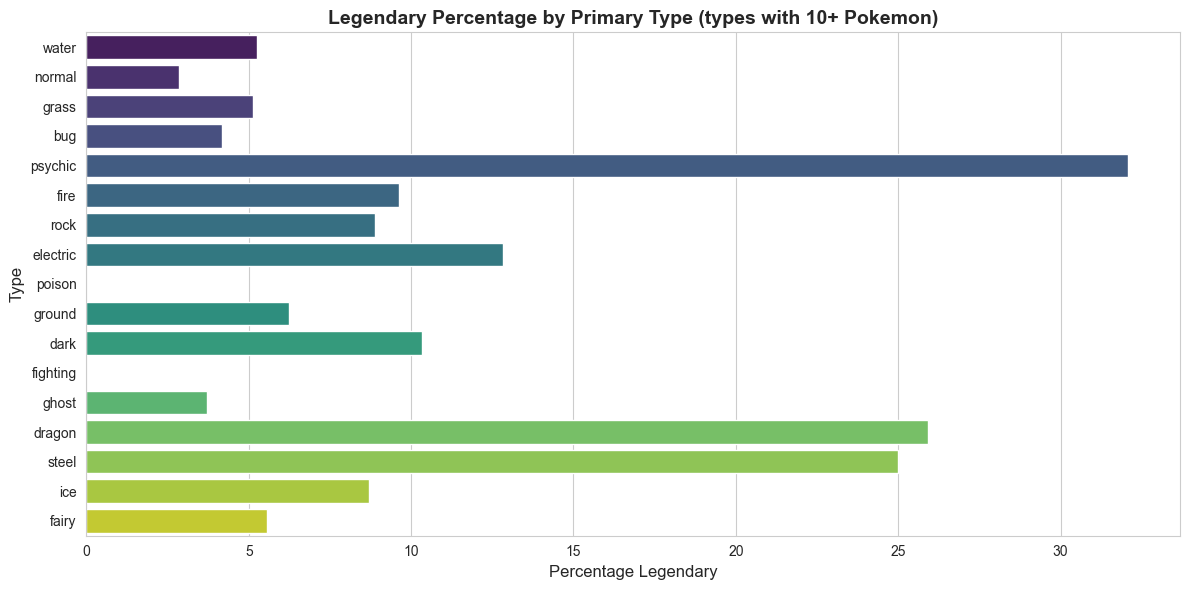

In [87]:
# type vs legendary
legendary = pd.crosstab(df["type1"], df["is_legendary"], margins=True)
print("Type1 vs Legendary distribution:")
print(legendary)

legendarypct = pd.crosstab(df["type1"], df["is_legendary"], normalize="index") * 100
print("\nPercentage legendary by type:")
print(legendarypct.round(2))

# filter for types with at least 10 pokemon for readability
typect = df["type1"].value_counts()
filteredlegendary = legendarypct.loc[typect[typect >= 10].index]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=filteredlegendary[1], y=filteredlegendary.index, palette="viridis", ax=ax)
ax.set_title("Legendary Percentage by Primary Type (types with 10+ Pokemon)", fontsize=14, fontweight="bold")
ax.set_xlabel("Percentage Legendary", fontsize=12)
ax.set_ylabel("Type", fontsize=12)
plt.tight_layout()
plt.show()

### 8. Type Combinations
What combinations are the most common? That's the question I aim to answer here.

In [88]:
type2cleaned = df["type2"].fillna("none")
df["type_combination"] = df["type1"] + (" + " + type2cleaned)
combct = df["type_combination"].value_counts() # count of each combination

top10 = combct.head(10)
print("Top 10 type combinations:")
top10

Top 10 type combinations:


type_combination
water + none       61
normal + none      61
grass + none       37
psychic + none     35
fire + none        27
normal + flying    26
electric + none    26
fighting + none    22
bug + none         18
fairy + none       16
Name: count, dtype: int64

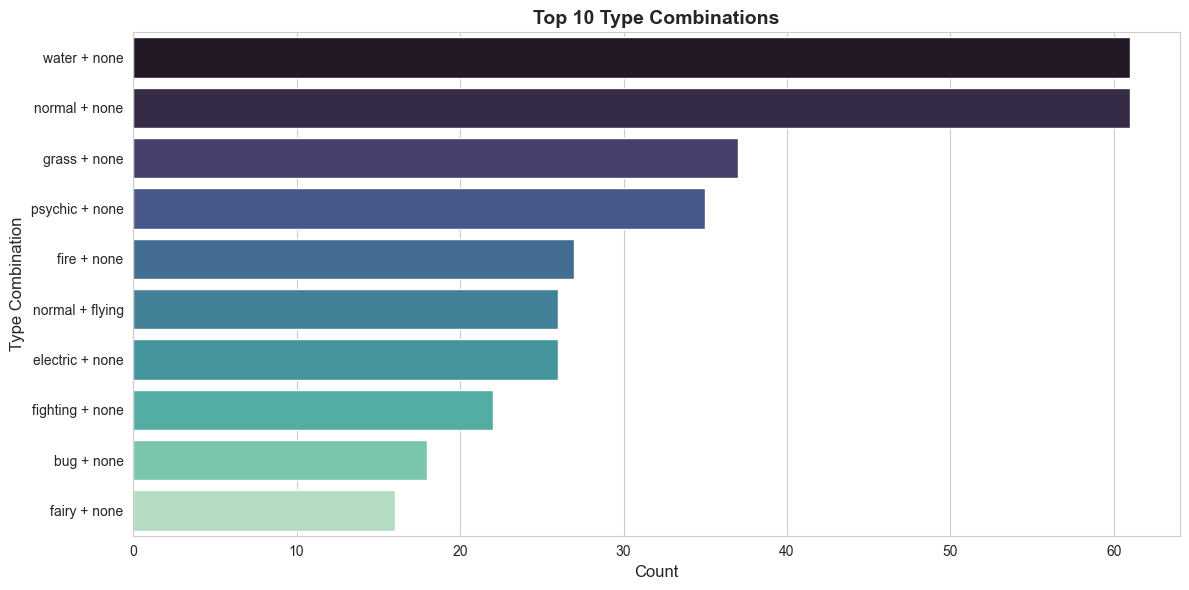

In [89]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top10.values, y=top10.index, palette="mako", ax=ax)
ax.set_title("Top 10 Type Combinations", fontsize=14, fontweight="bold")
ax.set_xlabel("Count", fontsize=12)
ax.set_ylabel("Type Combination", fontsize=12)
plt.tight_layout()
plt.show()

### 9. Top Performers by Base Total
The strongest Pokemon are almost all legendary, reinforcing the idea that legendary status is closely tied to raw power.

In [90]:
top15 = df.nlargest(15, "base_total")[["name", "type1", "type2", "base_total", "is_legendary"]]
print("Top 15 Pokemon by Base Total:")
print(top15)

high_performers = df[df["base_total"] >= 600]
print(f"\nPokemon with base total 600+: {len(high_performers)}")
print(f"Legendary percentage: {high_performers['is_legendary'].mean() * 100:.1f}%")
print(f"Type distribution:\n{high_performers['type1'].value_counts()}")

Top 15 Pokemon by Base Total:
          name    type1    type2  base_total  is_legendary
149     Mewtwo  psychic      NaN         780             1
383   Rayquaza   dragon   flying         780             1
381     Kyogre    water      NaN         770             1
382    Groudon   ground      NaN         770             1
492     Arceus   normal      NaN         720             1
717    Zygarde   dragon   ground         708             1
247  Tyranitar     rock     dark         700             0
372  Salamence   dragon   flying         700             0
375  Metagross    steel  psychic         700             0
379     Latias   dragon  psychic         700             1
380     Latios   dragon  psychic         700             1
444   Garchomp   dragon   ground         700             0
645     Kyurem   dragon      ice         700             1
718    Diancie     rock    fairy         700             1
248      Lugia  psychic   flying         680             1

Pokemon with base total 6

### 10. Machine Learning: Predicting Legendary Status
Here onwards, I'll proceed to build a logistic regression model to predict whether a Pokemon is legendary. Logistic regression gives interpretable coefficients, to observe exactly which features increase the odds of being legendary.

I'm using stats, capture rate, generation, and one‑hot encoded type columns as predictors.

In [91]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

print("ML libraries imported.")

ML libraries imported.


In [92]:
# prepare features and target
ml_df = df.copy()

# fill missing type2 with 'None' for encoding
ml_df["type2"] = ml_df["type2"].fillna("none")
ml_df["capture_rate"] = pd.to_numeric(ml_df["capture_rate"], errors="coerce")
ml_df = ml_df.dropna(subset=["weight_kg", "capture_rate", "base_happiness", "height_m"])
# select features
features = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed", "base_total", "capture_rate", "base_happiness", "weight_kg", "height_m", "generation", "type1", "type2"]
target = "is_legendary"

x = ml_df[features]
y = ml_df[target]

# one-hot encode type columns
x = pd.get_dummies(x, columns=["type1", "type2"], drop_first=False)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(x_train)} Pokemon")
print(f"Test set: {len(x_test)} Pokemon")
print(f"Legendary percentage in training: {y_train.mean() * 100:.1f}%")
print(f"Legendary percentage in test: {y_test.mean() * 100:.1f}%")

Training set: 624 Pokemon
Test set: 156 Pokemon
Legendary percentage in training: 8.8%
Legendary percentage in test: 9.0%


In [93]:
# train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(x_train, y_train)

# predictions
y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1]

# evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Model performance on test set [in %]:")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall: {rec * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")
print(f"ROC-AUC: {auc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-legendary", "Legendary"]))

Model performance on test set [in %]:
Accuracy: 94.23%
Precision: 61.90%
Recall: 92.86%
F1 Score: 74.29%
ROC-AUC: 97.18%

Classification Report:
               precision    recall  f1-score   support

Non-legendary       0.99      0.94      0.97       142
    Legendary       0.62      0.93      0.74        14

     accuracy                           0.94       156
    macro avg       0.81      0.94      0.86       156
 weighted avg       0.96      0.94      0.95       156



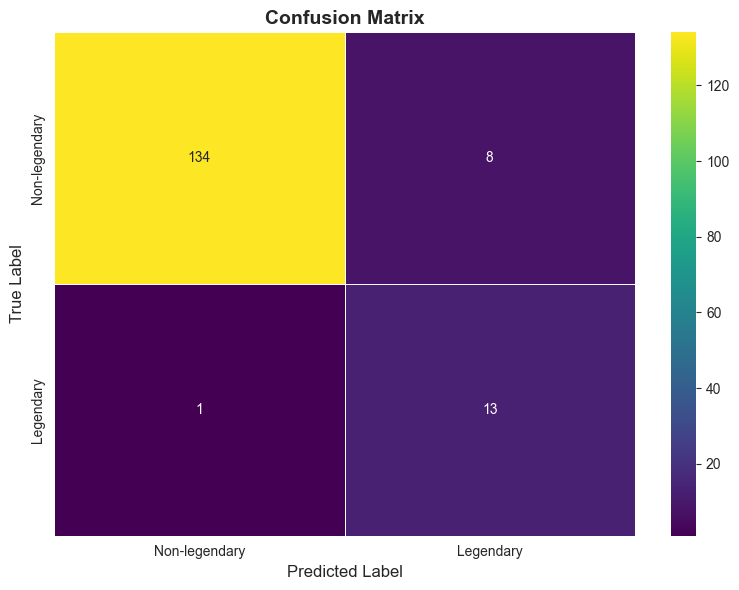

In [94]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=["Non-legendary", "Legendary"], yticklabels=["Non-legendary", "Legendary"], linewidth=0.5, ax=ax)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

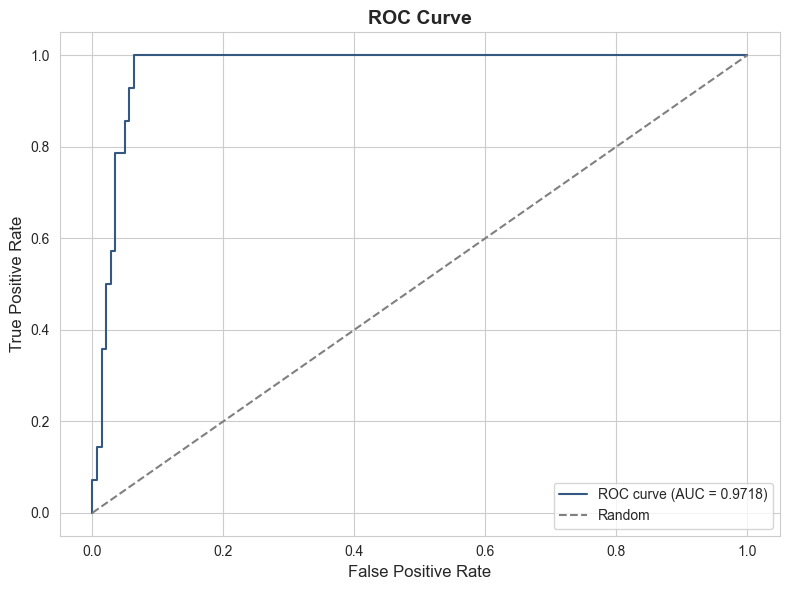

In [95]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba) # fpr: false pos, tpr: true pos, _: thresholds, which is basically cutoff vals for prediction probabilities

fig, ax = plt.subplots(figsize=(8, 6)) 
ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})", color=secondary) # auc: area under curve, measures how well model can distinguish between classes [legendary/non-legendary]
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [96]:
# feature importance from coefficients
coef_df = pd.DataFrame({"Feature": x.columns, "Coefficient": model.coef_[0]})
coef_df["abs_coef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.reset_index(drop=True).head(15)

print("Top 15 most influential features:")
coef_df[["Feature", "Coefficient"]]

Top 15 most influential features:


,Feature,Coefficient
0,hp,0.903162
1,attack,0.774871
2,defense,0.692879
3,sp_attack,0.314800
4,sp_defense,0.515503
5,speed,1.393030
6,base_total,1.130986
7,capture_rate,-2.518861
8,base_happiness,-1.512507
9,weight_kg,0.399075


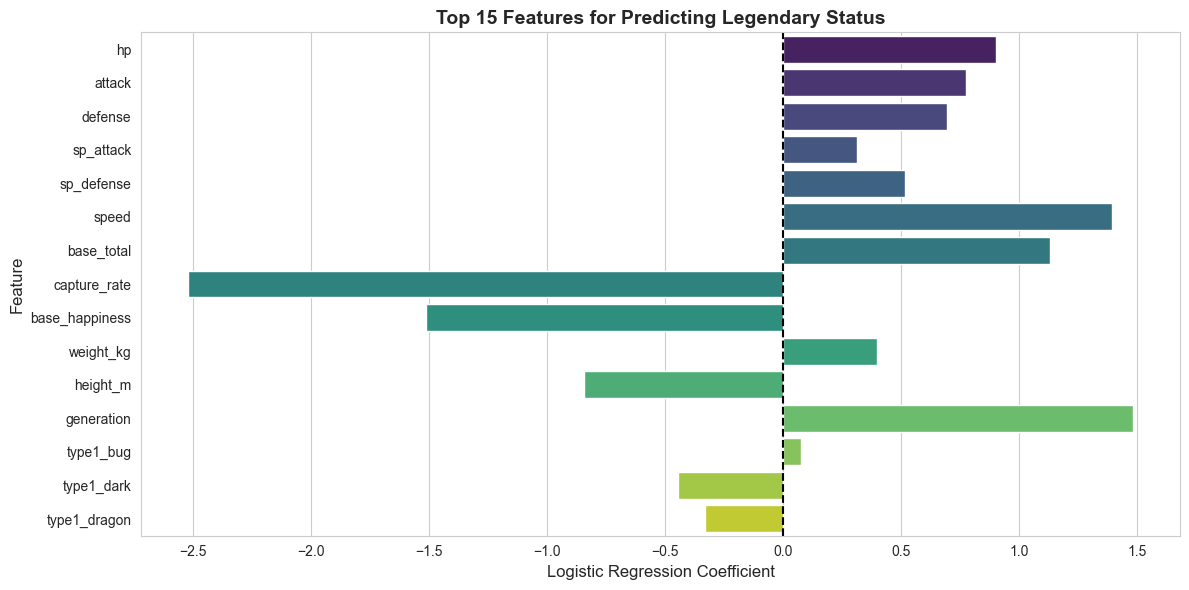

In [97]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df, palette="viridis", ax=ax)
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Top 15 Features for Predicting Legendary Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Logistic Regression Coefficient", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

# why -1 to 1?
#  coefs in a logistic regression can be interpreted as follows: if a coef has pos value, it means it increases chances of pokemon to be legendary. if neg, then it reduces chances of being legendary.

In [98]:
# cross-validation
cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy")
print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard deviation: {cv_scores.std() * 100:.2f}%")


Cross-validation accuracy scores: [0.928      0.928      0.92       0.928      0.91935484]
Mean CV accuracy: 92.47%
Standard deviation: 0.41%


In [99]:
import joblib
# saving the model
joblib.dump(model, "pokemon_legendary_model.pkl")
print("Model saved as 'pokemon_legendary_model.pkl'.")

Model saved as 'pokemon_legendary_model.pkl'.


### Machine Learning Takeaway

The model achieved the following performance on the test data:
* Accuracy: 94.23%
* Precision: 61.90%
* Recall: 92.86%
* F1 Score: 74.29%
* ROC-AUC: 97.18%
* Mean Cross-Validation Accuracy: 92.47%

These results show that logistic regression can very effectively identify legendary Pokemon. The high ROC-AUC indicates excellent discrimination between the two classes.

The most influential features are special attack, base total, and capture rate [lower capture rate = rarer]. Types such as Psychic and Dragon also have strong positive coefficients, confirming what was seen in the EDA.

### Conclusions and Observations

Legendary Pokemon have significantly higher stats across the board, with special attack being the most distinguishing feature. They are often Psychic, Dragon, or Fire types and have very low capture rates.

Most Pokemon are dual‑type [over 50%], but being dual‑type does not guarantee higher stats. Legendary Pokemon are more common in later generations [especially generations 3‑5] and are generally heavier than non‑legendary species.

The logistic regression model confirms the visual findings: base total, special attack, and type are the strongest predictors of legendary status. The model's high accuracy suggests these features capture the essential differences.